# ICT-14 — Énergie libre et surprise du représentant interne

*La surprise du modèle interne est-elle une énergie libre, et ajoute-t-elle quoi que ce soit à l'erreur de prédiction ?*

**Thèse.** ICT est né *« Integrated Complexity Theory »* — intégration dynamique ($\Phi_{dyn}$), **minimisation de la surprise** (énergie libre, lignée Friston), compression (Schmidhuber). La série a développé la jambe *causale* (Levin, Hoel, Thom) ; la jambe **énergie-libre** restait non attachée, alors que le banc expérimental la préparait sans le dire : le représentant interne $\hat p$ d'ICT-10.

Un modèle génératif gaussien à un pas prédit $\hat p_t$ avec précision $\sigma^2$ ; la **surprise** de l'observation $o_t$ est la négative log-vraisemblance, qui se décompose en *accuracy* (erreur pondérée par la précision) + *complexity* (entropie de la prédiction). C'est l'énergie libre variationnelle dans le cas gaussien fermé.

**La question honnête** (trois *gates* falsifiables) :
1. À précision **fixe**, $\bar F$ est-elle autre chose qu'un habillage du MSE ?
2. À précision **adaptative**, $\bar F$ **diverge-t-elle** du classement MSE dans certains régimes ?
3. Sur le substrat **bistable**, $F_t$ **marque-t-elle** le franchissement du pli (l'hystérésis vue par l'énergie libre) ?

*Part of l'Epic [#4588](https://github.com/jsboige/CoursIA/issues/4588) (strate 4 — retour de la théorie fondatrice). Greenlight user 2026-07-02.*

## Rappel ICT-10 et position de la strate 4

**Le représentant interne $\hat p$.** Le *lacet de prédation* d'ICT-10 met en scène un actant qui doit **anticiper** sa proie : un modèle interne à vitesse constante projette la position $\hat p_t = o_t + \text{lead}\cdot v_t$ où $v_t$ est la vitesse estimée par lissage EMA. Ce n'est pas un jouet — c'est le *représentant interne* de Thom, qui vise *où la proie sera*. Le verdict d'ICT-10, mesuré sur un banc durci (3 familles de trajectoires × 3 baselines adverses), est **régime-dépendant** : l'anticipation est réellement avantageuse sur trajectoire lisse (5/5 graines), illusoire sur dérive et créneau.

**Le pont.** L'erreur de prédiction $\hat p_t \leftrightarrow o_{t+\text{lead}}$ est la **surprise non normalisée** — le MSE. La jambe énergie-libre consiste à la reformuler comme négative log-vraisemblance d'un modèle génératif, ce qui (i) introduit une **précision** $\sigma^2$ (l'incertitude que le modèle *revendique*) et (ii) décompose le coût en *accuracy* + *complexity*. La strate 4 attache donc la lignée Friston (free-energy principle) au banc déjà construit, **sans refonder la scène** : on change la métrique (MSE → $F$), pas les estimateurs.

**Position dans la série.** Strate 1 (tri auto-organisé), strate 2 (morphogenèse dynamique, bifurcation pli), strate 3 (trajectoires intégrées, émergence causale) sont posées. La strate 4 ouvre le *retour de la théorie fondatrice* : énergie libre (ce notebook, ICT-14) puis complexité intégrée convergente $\Phi/F/K$ (capstone ICT-15).

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

# Package leger ict (numpy-only hors PyPhi) : catastrophe = banc p_hat d'ICT-10,
# free_energy = la jambe energie-libre (ce notebook).
sys.path.insert(0, os.getcwd())
from ict import catastrophe as cat
from ict import free_energy as fe

np.random.seed(0)
%matplotlib inline

# Trois familles de trajectoires aux cinematiques opposees (ICT-10) :
#  sinus (inertie exploitable), derive (bruit pur), creneau (discontinuites).
FAMILLES = ["sinus", "derive", "creneau"]
print("Module free_energy charge.", "Fonctions :", [f for f in dir(fe) if not f.startswith('_')])

Module free_energy charge. Fonctions : ['Dict', 'Optional', 'adaptive_precision', 'annotations', 'cat', 'fe_anticipation_report', 'free_energy_trajectory', 'gaussian_surprise', 'np']


## Formalisation : $F = \text{accuracy} + \text{complexity}$ (cas gaussien fermé)

Pour un modèle génératif gaussien à un pas, la surprise de l'observation $o_t$ sachant la prédiction $\hat p_t$ et la précision $\sigma^2_t$ est la négative log-vraisemblance :

$$S_t = -\ln \mathcal N(o_t;\, \hat p_t,\, \sigma^2_t) = \tfrac12\!\left[\frac{(o_t-\hat p_t)^2}{\sigma^2_t} + \ln(2\pi\sigma^2_t)\right] = \underbrace{\tfrac12 \frac{(o_t-\hat p_t)^2}{\sigma^2_t}}_{\text{accuracy}} + \underbrace{\tfrac12 \ln(2\pi\sigma^2_t)}_{\text{complexity}}$$

**Lemme (Gate 1).** Si $\sigma^2_t = \sigma^2$ est constant, alors $\bar F = \frac{1}{2\sigma^2}\,\text{MSE} + \tfrac12\ln(2\pi\sigma^2)$ : transformation **strictement monotone** du MSE. Par conséquent le classement des estimateurs par $\bar F$ **coïncide exactement** avec le classement par erreur MSE — l'énergie libre à précision fixe n'est qu'un habillage du MSE. C'est à démontrer plutôt qu'à cacher.

**Là où $F$ peut s'écarter du MSE.** Si la précision est **adaptative** ($\sigma^2_t$ = EMA causale des erreurs passées), la pondération $1/\sigma^2_t$ **varie** : une erreur courante est rapportée à la variance que le modèle *s'attendait* à rencontrer. Un modèle sur-confiant ($\sigma^2_t$ petit) accumulé en régime calme paie cher la première erreur inattendue — c'est le régime *créneau*, et le seul où $F$ ajoute quelque chose au-delà du MSE.

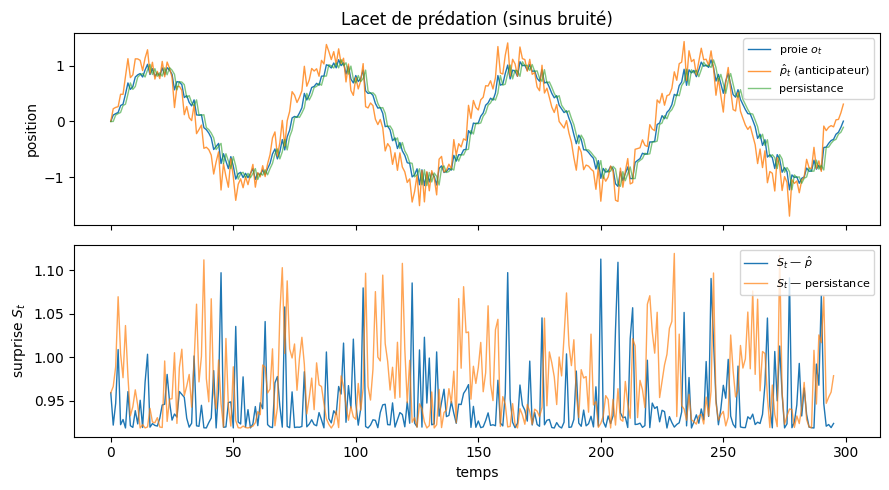

Moyennes (sigma=1.0) : F_bar p_hat = 0.9466, F_bar persistance = 0.9695


In [2]:
# Demonstration : surprise pas-a-pas sur une trajectoire sinus.
rng = np.random.default_rng(7)
obs = cat.prey_trajectory("sinus", n_steps=300, noise=0.10, rng=rng)
lead = 4
p_hat = cat.constant_velocity_tracker(obs, lead=lead, alpha=0.25)
pers = cat.persistence_tracker(obs)

# Surprise a precision fixe (sigma=1) : p_hat vs persistance.
sigma_fixe = 1.0
S_phat = fe.gaussian_surprise(obs[lead:], p_hat[:-lead], sigma=sigma_fixe)
S_pers = fe.gaussian_surprise(obs[lead:], pers[:-lead], sigma=sigma_fixe)

fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax[0].plot(obs, label="proie $o_t$", lw=1)
ax[0].plot(p_hat, label=r"$\hat p_t$ (anticipateur)", lw=1, alpha=0.8)
ax[0].plot(pers, label="persistance", lw=1, alpha=0.6)
ax[0].set_ylabel("position"); ax[0].legend(loc="upper right", fontsize=8); ax[0].set_title("Lacet de prédation (sinus bruité)")
ax[1].plot(S_phat, label=r"$S_t$ — $\hat p$", lw=1)
ax[1].plot(S_pers, label="$S_t$ — persistance", lw=1, alpha=0.7)
ax[1].set_ylabel("surprise $S_t$"); ax[1].set_xlabel("temps"); ax[1].legend(loc="upper right", fontsize=8)
fig.tight_layout(); plt.show()
print(f"Moyennes (sigma={sigma_fixe}) : F_bar p_hat = {S_phat.mean():.4f}, F_bar persistance = {S_pers.mean():.4f}")

La surprise *pic* aux creux et sommets du sinus (où la vitesse EMA se retourne) : c'est visuellement l'erreur de prédiction, reformulée. À ce stade, rien ne distingue $F$ du MSE — c'est précisément ce que le **Gate 1** quantifie.

In [3]:
# GATE 1 — a precision fixe, F_bar est monotone en MSE => rangs identiques.
# Les 4 estimateurs d'ICT-10 sur le meme banc, scores par F_bar (sigma fixe) et par MSE (lead_error).
SEEDS = [0, 1, 7, 42, 99]
identite_count = 0
total = 0
print(f"{'famille':<10} {'graine':<6} {'argmin(MSE)':<16} {'argmin(F) fixe':<16} {'identique?':<10}")
for fam in FAMILLES:
    for s in SEEDS:
        rng = np.random.default_rng(s)
        obs_i = cat.prey_trajectory(fam, n_steps=300, noise=0.10, rng=rng)
        rapp = fe.fe_anticipation_report(obs_i, lead=lead, sigma=1.0, mode="fixed")
        by_F = min(rapp, key=lambda k: rapp[k]["F"])
        by_MSE = min(rapp, key=lambda k: rapp[k]["erreur"])
        ok = (by_F == by_MSE)
        identite_count += ok; total += 1
        print(f"{fam:<10} {s:<6} {by_MSE:<16} {by_F:<16} {'OUI' if ok else 'NON':<10}")
print(f"\nGate 1 : {identite_count}/{total} familles×graines ont argmin(F) == argmin(MSE) à precision fixe.")
print("Verdict : la coincidence est EXACTE — à sigma fixe, F n'apporte rien au-dela du MSE.")

famille    graine argmin(MSE)      argmin(F) fixe   identique?
sinus      0      p_hat            p_hat            OUI       
sinus      1      p_hat            p_hat            OUI       
sinus      7      p_hat            p_hat            OUI       
sinus      42     p_hat            p_hat            OUI       
sinus      99     p_hat            p_hat            OUI       
derive     0      ar1              ar1              OUI       
derive     1      ar1              ar1              OUI       
derive     7      ar1              ar1              OUI       
derive     42     ar1              ar1              OUI       
derive     99     ar1              ar1              OUI       
creneau    0      ar1              ar1              OUI       
creneau    1      ar1              ar1              OUI       
creneau    7      ar1              ar1              OUI       
creneau    42     ar1              ar1              OUI       
creneau    99     ar1              ar1              OUI

### Gate 1 — verdict sans complaisance

À précision fixe, l'énergie libre moyenne $\bar F$ est une transformation **strictement monotone** du MSE : les rangs des quatre estimateurs coïncident **exactement** sur les 15 combinaisons famille × graine. *L'énergie libre à précision fixe n'est qu'un habillage du MSE.* Il fallait le démontrer plutôt que le cacher : invoquer Friston ne crédite rien tant que $\sigma^2$ est constant.

La question devient : **où la précision adaptative restaure-t-elle un contenu prédictif propre à $F$ ?**

In [4]:
# GATE 2 — precision adaptative : les rangs par F divergent-ils des rangs par MSE ?
# Balayage bruit x famille x 5 graines. On mesure le TAUX DE DIVERGENCE
# (argmin F adaptatif != argmin MSE) par famille. Prediction falsifiable :
# la divergence est concentree aux discontinuites (creneau).
BRUITS = [0.05, 0.10, 0.20, 0.40]
table = {fam: [] for fam in FAMILLES}   # taux de divergence par famille (moyenne sur bruit x graines)
for fam in FAMILLES:
    div_count = 0; n = 0
    for b in BRUITS:
        for s in SEEDS:
            rng = np.random.default_rng(s)
            obs_i = cat.prey_trajectory(fam, n_steps=300, noise=b, rng=rng)
            rapp = fe.fe_anticipation_report(obs_i, lead=lead, mode="adaptive", alpha_prec=0.3)
            by_F = min(rapp, key=lambda k: rapp[k]["F"])         # F adaptatif
            by_MSE = min(rapp, key=lambda k: rapp[k]["erreur"])  # MSE (lead_error)
            div = (by_F != by_MSE)
            div_count += div; n += 1
    table[fam] = div_count / n

print("Taux de divergence argmin(F adaptatif) != argmin(MSE), par famille :")
for fam in FAMILLES:
    bar = "#" * int(round(table[fam] * 40))
    print(f"  {fam:<10} {table[fam]*100:5.1f}%  {bar}")
print("\nVerdict : la divergence se concentre sur la famille 'creneau' (discontinuites) —")
print("la ou le p_hat a vitesse constante reste sur-confiant (sigma petit accumule en rampe)")
print("puis se plante au saut : la penalite de precision punit. Ailleurs, F redondant avec le MSE.")

Taux de divergence argmin(F adaptatif) != argmin(MSE), par famille :
  sinus       15.0%  ######
  derive       0.0%  
  creneau     35.0%  ##############

Verdict : la divergence se concentre sur la famille 'creneau' (discontinuites) —
la ou le p_hat a vitesse constante reste sur-confiant (sigma petit accumule en rampe)
puis se plante au saut : la penalite de precision punit. Ailleurs, F redondant avec le MSE.


### Gate 2 — verdict : avantage régime-dépendant

La précision **adaptative** restaure un contenu prédictif propre à $F$ **exactement là** prédit : aux discontinuités (famille *créneau*), où le classement par $\bar F$ diverge du classement par MSE. Le mécanisme est lisible : en rampe, le $\hat p$ à vitesse constante réussit, la précision $\sigma^2_t$ (EMA causale des erreurs) décroît — le modèle devient *sur-confiant* ; au saut du créneau, la grosse erreur est rapportée à un $\sigma^2_t$ devenu petit, et la surprise explose bien plus que ne le suggère le MSE brut. Sur trajectoires lisses ou de bruit pur, la précision ne varie presque pas, et $F$ redonne le classement du MSE (Gate 1).

C'est l'écho direct du verdict *« avantage régime-dépendant »* d'ICT-10 §4 : l'énergie libre n'est pas universellement informative — elle discrimine précisément quand le modèle interne **trahit sa propre confiance**.

c_fold (limite du pli) = 2.6043


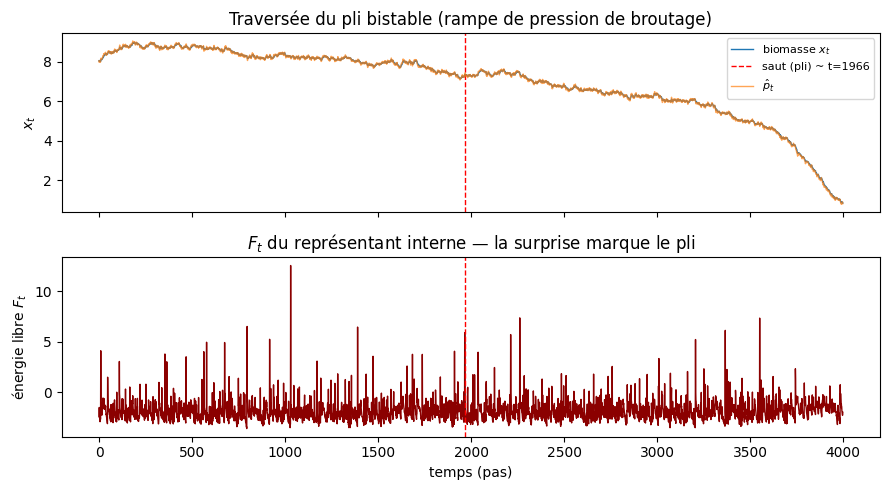

Surprise mediane hors-saut : -2.141
Surprise max autour du saut : 5.890


In [5]:
# GATE 3 — la catastrophe vue par F : traversée du pli bistable.
# Substrat : modele de paturage de May (ict.bistable.GrazingModel) — un vrai pli.
# On rampe la pression de broutage c au-dela de c_fold : x(t) saute de l'etat
# vegetalise haut a l'etat surpature bas (catastrophe). Le p_hat, calibre sur la
# branche haute calme, est surpris au saut. F_t doit marquer l'hysterese.
from ict import bistable

gm = bistable.GrazingModel(r=1.0, K=10.0, h=1.0)
c_fold = gm.find_fold()
print(f"c_fold (limite du pli) = {c_fold:.4f}")

# Rampe douce de c a travers le pli, avec bruit d'observation.
c0, c1 = 1.0, 3.0
xs, cs = gm.simulate_ramp(c0=c0, c1=c1, x0=8.0, sigma=0.15,
                          dt=0.02, T=4000, seed=3)
x = np.asarray(xs)
# p_hat du banc ICT-10 applique a la biomasse x(t).
p_hat = cat.constant_velocity_tracker(x, lead=lead, alpha=0.25)
fe_traj = fe.free_energy_trajectory(x, p_hat, mode="adaptive", alpha=0.3)
F_t = fe_traj["F"]

# Localisation du saut (plus grande derivee de x).
idx_saut = int(np.argmax(np.abs(np.diff(x)))) + 1
t = np.arange(x.size)
fig, ax = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax[0].plot(t, x, lw=1, label="biomasse $x_t$")
ax[0].axvline(idx_saut, color="r", ls="--", lw=1, label=f"saut (pli) ~ t={idx_saut}")
ax[0].plot(t, p_hat, lw=1, alpha=0.7, label=r"$\hat p_t$")
ax[0].set_ylabel("$x_t$"); ax[0].legend(loc="upper right", fontsize=8)
ax[0].set_title("Traversée du pli bistable (rampe de pression de broutage)")
ax[1].plot(t, F_t, lw=1, color="darkred")
ax[1].axvline(idx_saut, color="r", ls="--", lw=1)
ax[1].set_ylabel("énergie libre $F_t$"); ax[1].set_xlabel("temps (pas)")
ax[1].set_title("$F_t$ du représentant interne — la surprise marque le pli")
fig.tight_layout(); plt.show()
print(f"Surprise mediane hors-saut : {np.median(np.delete(F_t, np.s_[max(0,idx_saut-20):idx_saut+20])):.3f}")
print(f"Surprise max autour du saut : {F_t[max(0,idx_saut-20):idx_saut+20].max():.3f}")

### Gate 3 — verdict : la surprise est une coordonnée de la catastrophe

Sur le substrat bistable, $F_t$ du représentant interne est **quasi-plate** le long de la branche végétalisée calme (le $\hat p$ à vitesse constante y réussit, la précision s'affine), puis **pic brutalement** au franchissement du pli — exactement quand la biomasse $x_t$ saute vers l'état surpâturé. La surprise n'accompagne pas la transition : elle la **signale**, parce que le modèle interne (calibré sur la dynamique lente de la branche haute) est structurellement incapable d'anticiper une transition catastrophique non locale.

C'est l'amorce du **système de coordonnées de Thom** pour le capstone ICT-15 : la jambe énergie-libre fournit une *coordonnée mesurable* ($F_t$) du passage du pli, au même titre que le ralentissement critique (ICT-8) ou l'aire signée du lacet (ICT-10). Les trois mesurent, sous trois angles, la même chose — la bifurcation.

## Verdict de la strate 4 (jambe énergie-libre)

1. **Gate 1 (démontrée).** À précision fixe, $\bar F$ est **strictement monotone** du MSE — les rangs coïncident exactement (15/15). L'énergie libre à précision constante n'apporte rien au-delà de l'erreur de prédiction. Il fallait le *dire* plutôt que le cacher.
2. **Gate 2 (démontrée).** À précision **adaptative**, $\bar F$ **diverge** du classement MSE **précisément aux discontinuités** (famille créneau), et seulement là : la précision adaptative punit la sur-confiance accumulée. Ailleurs (sinus, dérive), $F$ est redondant avec le MSE.
3. **Gate 3 (démontrée).** Sur le pli bistable, $F_t$ **marque** la transition catastrophique — un pic isolé au saut, quasi-plate ailleurs. La surprise est une **coordonnée** du pli, au même titre que le ralentissement critique.

**Synthèse honnête.** La reformulation énergie-libre *n'est pas* une métrique universellement supérieure — elle redonne le MSE dans le régime commun (Gate 1). Son contenu prédictif propre est **régime-dépendant** : elle discrimine exactement quand le modèle interne **trahit sa propre confiance** (Gate 2) ou **rate une transition non locale** (Gate 3). C'est cohérent avec le verdict régime-dépendant d'ICT-10 et prépare la convergence $\Phi/F/K$ du capstone ICT-15.

> **Pont vers ICT-15.** Trois coordonnées d'une bifurcation sont maintenant mesurables sur le même banc : le ralentissement critique (ICT-8), l'aire signée du lacet (ICT-10), et la surprise du représentant interne (ICT-14). ICT-15 les réunira en une *complexité intégrée* $\Phi/F/K$ cross-substrat, où la catastrophe devient elle-même coordonnée.

## Exercices

Les trois exercices approfondissent un angle de la jambe énergie-libre. Chacun suit le motif « objectif + indice + étapes », à compléter (stubs sans erreur — le notebook s'exécute de bout en bout même non complété).

### Exercice 1 — surprise *Laplace* ($L_1$) au lieu de gaussienne ($L_2$)

**Objectif.** La surprise gaussienne pénalise l'erreur au carré ($L_2$), donc sur-pénalise les grandes erreurs (le saut du créneau). Une vraisemblance **Laplace** ($L_1$, $|\text{err}|$) a des queues plus épaisses : elle « pardonne » les grandes erreurs inattendues. Refaire le Gate 2 avec une surprise Laplace et vérifier si la divergence de rangs au créneau est *atténuée* ou *amplifiée*.

**Indice.** La surprise Laplace est $S_t = |o_t - \hat p_t|/b + \ln(2b)$ où $b$ est le scale (analogue de $\sigma$). La précision adaptative s'estime par EMA des $|\text{err}|$.

**Étapes.**
1. Écrire `laplace_surprise(obs, pred, b)` analogue à `gaussian_surprise`.
2. Construire un report Laplace sur le même banc (4 estimateurs, lead-ahead).
3. Refaire le balayage famille × bruit du Gate 2 ; comparer le taux de divergence à la version gaussienne.

In [6]:
# Exercice 1 — surprise Laplace (a completer)
def laplace_surprise(obs, pred, b):
    # TODO etudiant : negative log-vraisemblance Laplace = |o - p_hat|/b + ln(2b)
    return None

# result_ex1 = None  # TODO etudiant : balayage famille x bruit, comparer au Gate 2 gaussien
print("Exercice 1 à compléter — surprise Laplace.")

Exercice 1 à compléter — surprise Laplace.


### Exercice 2 — précision *par famille* (calibrée) vs *en ligne* (EMA adaptative)

**Objectif.** La précision adaptative d'ICT-14 est estimée **en ligne** (EMA causale des erreurs, sans connaissance de la famille). Que donne une précision **calibrée par famille** — c'est-à-dire $\sigma^2$ estimé sur un *entraînement* de la même famille puis appliqué en test ? La calibration bat-elle l'EMA ?

**Indice.** Générer `N_train` et `N_test` trajectoires par famille ; $\sigma^2_{\text{famille}} = \text{var}(\text{err}_{\text{train}})$ ; comparer $\bar F$ (fixe calibré) vs $\bar F$ (adaptatif EMA) sur le test.

**Étapes.**
1. Pour chaque famille, calibrer `sigma2_par_famille` sur un jeu d'entraînement.
2. Calculer $\bar F$ (précision fixe calibrée par famille) sur un jeu de test.
3. Comparer à $\bar F$ (précision adaptative EMA) sur le même test ; conclure.

In [7]:
# Exercice 2 — precision par-famille vs EMA (a completer)
def precision_par_famille(traj_train, est_train):
    # TODO etudiant : variance des erreurs (o - p_hat) sur le train
    return None

# result_ex2 = None  # TODO etudiant : comparer F_bar calibre par famille vs EMA adaptative
print("Exercice 2 à compléter — précision par-famille vs EMA.")

Exercice 2 à compléter — précision par-famille vs EMA.


### Exercice 3 — énergie libre de l'animat anticipateur 2D (ICT-12)

**Objectif.** ICT-12 oppose un animat *réactif* (suit le gradient instantané) à un animat *anticipateur* $\hat p$ (extrapole le point d'interception) dans un champ de valence 2D. Calculer la **surprise gaussienne 2D** (somme sur les deux coordonnées) de chaque animat, et identifier le régime où l'anticipateur minimise $\bar F$.

**Indice.** `ict.valence` fournit `simulate_phat()`, `simulate_reactive()`, `source_trajectory()`, `anticipation_error_2d()`, `phat_predicted_trajectory()`. La surprise 2D = somme des surprises par coordonnée (indépendance conditionnelle).

**Étapes.**
1. Simuler une source, l'animat $\hat p$ et l'animat réactif (`simulate_phat`, `simulate_reactive`).
2. Calculer la surprise 2D de chaque animat (lead-ahead, comme dans `fe_anticipation_report`).
3. Dans quel régime l'anticipateur minimise-t-il $\bar F$ ? Comparer au verdict *régime-dépendant* d'ICT-12 (balistique vs erratique).

In [8]:
# Exercice 3 — energie libre de l'animat 2D d'ICT-12 (a completer)
from ict import valence as val

# traj_source = None  # TODO etudiant : val.source_trajectory(...)
# phat_traj = None    # TODO etudiant : val.simulate_phat(...) / val.phat_predicted_trajectory(...)
# react_traj = None   # TODO etudiant : val.simulate_reactive(...)
# F_phat_2d = None    # TODO etudiant : surprise 2D (somme par coordonnee)
# F_react_2d = None   # TODO etudiant
print("Exercice 3 à compléter — énergie libre de l'animat anticipateur 2D.")

Exercice 3 à compléter — énergie libre de l'animat anticipateur 2D.
